In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Result Analysis and normalization**

In [ ]:
import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/NLP_project/results"
RAW_DIR = os.path.join(BASE_PATH, "raw")
OUT_DIR = os.path.join(BASE_PATH, "normalized")

os.makedirs(OUT_DIR, exist_ok=True)

TEXT_TO_NUM = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}

VALID_LABELS = {-1, 0, 1}


def normalize_columns(df):
    df.columns = [c.strip().lower() for c in df.columns]

    rename_map = {}
    if "text" in df.columns:
        rename_map["text"] = "review"
    if "sentence" in df.columns:
        rename_map["sentence"] = "review"
    if "pred" in df.columns:
        rename_map["pred"] = "prediction"
    if "gold" in df.columns:
        rename_map["gold"] = "label"

    if rename_map:
        df = df.rename(columns=rename_map)

    return df


def normalize_label_series(series):
    if series.dtype == object:
        series = series.astype(str).str.strip().str.lower()

        if series.isin(TEXT_TO_NUM.keys()).all():
            return series.map(TEXT_TO_NUM)

        try:
            numeric_series = pd.to_numeric(series)
            return numeric_series
        except:
            return series

    return series


def normalize_file(file_path):
    df = pd.read_csv(file_path)
    df = normalize_columns(df)

    required_cols = {"id", "review", "label", "prediction"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{os.path.basename(file_path)} 缺少字段: {missing}")

    df["label"] = normalize_label_series(df["label"])
    df["prediction"] = normalize_label_series(df["prediction"])

    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df["prediction"] = pd.to_numeric(df["prediction"], errors="coerce")

    bad_label = df.loc[~df["label"].isin(VALID_LABELS), "label"]
    bad_pred = df.loc[~df["prediction"].isin(VALID_LABELS), "prediction"]

    if not bad_label.empty:
        raise ValueError(
            f"{os.path.basename(file_path)} invalid: {sorted(bad_label.dropna().unique().tolist())}"
        )

    if not bad_pred.empty:
        raise ValueError(
            f"{os.path.basename(file_path)} invalid: {sorted(bad_pred.dropna().unique().tolist())}"
        )

    df["label"] = df["label"].astype(int)
    df["prediction"] = df["prediction"].astype(int)

    return df[["id", "review", "label", "prediction"]]


def batch_normalize():
    summary = []

    for filename in sorted(os.listdir(RAW_DIR)):
        if not filename.endswith(".csv"):
            continue

        input_path = os.path.join(RAW_DIR, filename)
        output_path = os.path.join(OUT_DIR, filename)

        try:
            df_norm = normalize_file(input_path)
            df_norm.to_csv(output_path, index=False)

            summary.append({
                "file": filename,
                "rows": len(df_norm),
                "columns": list(df_norm.columns),
                "label_values": sorted(df_norm["label"].unique().tolist()),
                "pred_values": sorted(df_norm["prediction"].unique().tolist()),
                "status": "ok"
            })

            print(f"[OK] {filename}")

        except Exception as e:
            summary.append({
                "file": filename,
                "rows": None,
                "columns": None,
                "label_values": None,
                "pred_values": None,
                "status": f"error: {e}"
            })

            print(f"[ERROR] {filename}: {e}")

    return pd.DataFrame(summary)


summary_df = batch_normalize()
summary_df

[OK] bert_after_s0.csv
[OK] bert_after_s1.csv
[OK] bert_before_s0.csv
[OK] bert_before_s1.csv
[OK] lexicon_rule_s0.csv
[OK] lexicon_rule_s1.csv
[OK] qwen_0.6b_after_s0.csv
[OK] qwen_0.6b_after_s1.csv
[ERROR] qwen_0.6b_before_s0.csv: qwen_0.6b_before_s0.csv invalid: []
[ERROR] qwen_0.6b_before_s1.csv: qwen_0.6b_before_s1.csv invalid: []
[OK] qwen_1.7b_after_s0.csv
[OK] qwen_1.7b_after_s1.csv
[OK] qwen_1.7b_before_s0.csv
[OK] qwen_1.7b_before_s1.csv
[OK] qwen_4b_after_s0.csv
[OK] qwen_4b_after_s1.csv
[ERROR] qwen_4b_before_s0.csv: qwen_4b_before_s0.csv invalid: []
[ERROR] qwen_4b_before_s1.csv: qwen_4b_before_s1.csv invalid: []
[OK] svm_tfidf_s0.csv
[OK] svm_tfidf_s1.csv


,file,rows,columns,label_values,pred_values,status
0,bert_after_s0.csv,500.0,"[id, review, label, prediction]","[-1, 0, 1]","[-1, 0, 1]",ok
1,bert_after_s1.csv,500.0,"[id, review, label, prediction]","[-1, 0, 1]","[-1, 0, 1]",ok
2,bert_before_s0.csv,500.0,"[id, review, label, prediction]","[-1, 0, 1]","[-1, 1]",ok
3,bert_before_s1.csv,500.0,"[id, review, label, prediction]","[-1, 0, 1]","[-1, 0, 1]",ok
4,lexicon_rule_s0.csv,500.0,"[id, review, label, prediction]","[-1, 0, 1]","[-1, 0, 1]",ok
5,lexicon_rule_s1.csv,500.0,"[id, review, label, prediction]","[-1, 0, 1]","[-1, 0, 1]",ok
6,qwen_0.6b_after_s0.csv,500.0,"[id, review, label, prediction]","[-1, 0, 1]","[-1, 0, 1]",ok
7,qwen_0.6b_after_s1.csv,500.0,"[id, review, label, prediction]","[-1, 0, 1]","[-1, 0, 1]",ok
8,qwen_0.6b_before_s0.csv,NaN,None,None,None,error: qwen_0.6b_before_s0.csv invalid: []
9,qwen_0.6b_before_s1.csv,NaN,None,None,None,error: qwen_0.6b_before_s1.csv invalid: []


# **Experiments**

## **Experiment A: Overall Performance Comparison**

In [73]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

DATA_DIR = "/content/drive/MyDrive/NLP_project/results/normalized"
OUTPUT_DIR = "/content/drive/MyDrive/NLP_project/results/experiment_A_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

LABELS = [-1, 0, 1]

FILE_MAP = {
    "svm_tfidf_s0.csv": ("SVM", "source0"),
    "svm_tfidf_s1.csv": ("SVM", "source1"),

    "lexicon_rule_s0.csv": ("Lexicon", "source0"),
    "lexicon_rule_s1.csv": ("Lexicon", "source1"),

    "bert_before_s0.csv": ("BERT before", "source0"),
    "bert_before_s1.csv": ("BERT before", "source1"),
    "bert_after_s0.csv": ("BERT after", "source0"),
    "bert_after_s1.csv": ("BERT after", "source1"),

    "qwen_0.6b_before_s0.csv": ("Qwen0.6 before", "source0"),
    "qwen_0.6b_before_s1.csv": ("Qwen0.6 before", "source1"),
    "qwen_0.6b_after_s0.csv": ("Qwen0.6 after", "source0"),
    "qwen_0.6b_after_s1.csv": ("Qwen0.6 after", "source1"),

    "qwen_1.7b_before_s0.csv": ("Qwen1.7 before", "source0"),
    "qwen_1.7b_before_s1.csv": ("Qwen1.7 before", "source1"),
    "qwen_1.7b_after_s0.csv": ("Qwen1.7 after", "source0"),
    "qwen_1.7b_after_s1.csv": ("Qwen1.7 after", "source1"),

    "qwen_4b_before_s0.csv": ("Qwen4 before", "source0"),
    "qwen_4b_before_s1.csv": ("Qwen4 before", "source1"),
    "qwen_4b_after_s0.csv": ("Qwen4 after", "source0"),
    "qwen_4b_after_s1.csv": ("Qwen4 after", "source1"),
}

model_order = [
    "Lexicon",
    "SVM",
    "BERT before",
    "BERT after",
    "Qwen0.6 before",
    "Qwen0.6 after",
    "Qwen1.7 before",
    "Qwen1.7 after",
    "Qwen4 before",
    "Qwen4 after"
]

source_order = ["source0", "source1"]

all_data = []
missing_files = []

for file_name, (model_name, source_name) in FILE_MAP.items():
    file_path = os.path.join(DATA_DIR, file_name)

    if not os.path.exists(file_path):
        missing_files.append(file_name)
        continue

    df = pd.read_csv(file_path)

    required_cols = {"id", "review", "label", "prediction"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"{file_name} is missing required columns: {required_cols}")

    df = df.copy()
    df["Model"] = model_name
    df["Source"] = source_name
    df["File"] = file_name

    all_data.append(df)

if len(all_data) == 0:
    raise ValueError("No valid result files were loaded. Please check DATA_DIR and file names.")

full_df = pd.concat(all_data, ignore_index=True)

print("Loaded data shape:", full_df.shape)
print("\nLoaded models:")
print(sorted(full_df["Model"].unique().tolist()))
print("\nLoaded sources:")
print(sorted(full_df["Source"].unique().tolist()))

if missing_files:
    print("\nMissing files:")
    for f in missing_files:
        print(f)

print("\nUnique labels:", sorted(full_df["label"].dropna().unique().tolist()))
print("Unique predictions:", sorted(full_df["prediction"].dropna().unique().tolist()))

def compute_experiment_a_metrics(df):
    y_true = df["label"]
    y_pred = df["prediction"]

    accuracy = accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=LABELS,
        average="weighted",
        zero_division=0
    )

    return pd.Series({
        "Accuracy": accuracy,
        "Weighted_F1": weighted_f1,
        "Macro_Precision": macro_precision,
        "Macro_Recall": macro_recall,
        "Macro_F1": macro_f1
    })

Loaded data shape: (9942, 7)

Loaded models:
['BERT after', 'BERT before', 'Lexicon', 'Qwen0.6 after', 'Qwen0.6 before', 'Qwen1.7 after', 'Qwen1.7 before', 'Qwen4 after', 'Qwen4 before', 'SVM']

Loaded sources:
['source0', 'source1']

Unique labels: [-1, 0, 1]
Unique predictions: [-1, 0, 1]


### Table 1: Overall Results

In [74]:
metrics = [
    "Macro_F1",
    "Accuracy",
    "Weighted_F1",
    "Macro_Precision",
    "Macro_Recall"
]

df = table1[["Model", "Source"] + metrics].copy()

pivot_df = df.pivot(index="Model", columns="Source", values=metrics)

pivot_df = pivot_df.swaplevel(0, 1, axis=1)

pivot_df = pivot_df.sort_index(axis=1, level=[0, 1])

pivot_df = pivot_df.rename(columns={
    "source0": "Source0",
    "source1": "Source1"
}, level=0)

mean_df = df.groupby("Model")[metrics].mean()
mean_df.columns = pd.MultiIndex.from_product([["Mean"], mean_df.columns])

final_table = pd.concat([pivot_df, mean_df], axis=1)

desired_columns = pd.MultiIndex.from_tuples([
    ("Source0", "Macro_F1"),
    ("Source0", "Accuracy"),
    ("Source0", "Weighted_F1"),
    ("Source0", "Macro_Precision"),
    ("Source0", "Macro_Recall"),

    ("Source1", "Macro_F1"),
    ("Source1", "Accuracy"),
    ("Source1", "Weighted_F1"),
    ("Source1", "Macro_Precision"),
    ("Source1", "Macro_Recall"),

    ("Mean", "Macro_F1"),
    ("Mean", "Accuracy"),
    ("Mean", "Weighted_F1"),
    ("Mean", "Macro_Precision"),
    ("Mean", "Macro_Recall"),
])

final_table = final_table.reindex(columns=desired_columns)
final_table = final_table.sort_values(by=("Mean", "Macro_F1"), ascending=False)
final_table = final_table.round(4)
display(final_table)

final_table.to_csv(
    os.path.join(OUTPUT_DIR, "table_unified_full_performance_fixed.csv")
)

print("Saved: table_unified_full_performance_fixed.csv")

/tmp/ipykernel_1595/1200884830.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = df.groupby("Model")[metrics].mean()


Source0                                                    \
               Macro_F1 Accuracy Weighted_F1 Macro_Precision Macro_Recall   
Model                                                                       
Qwen4 after      0.8658   0.9405      0.9443          0.8467       0.8967   
Qwen1.7 after    0.8660   0.9425      0.9443          0.8536       0.8809   
Qwen0.6 after    0.8552   0.9405      0.9378          0.8833       0.8335   
BERT after       0.7584   0.8953      0.8914          0.7709       0.7502   
SVM              0.6436   0.8604      0.8380          0.8219       0.6475   
Qwen4 before     0.4671   0.6263      0.6391          0.4728       0.4961   
Qwen0.6 before   0.5093   0.6715      0.6772          0.5065       0.5182   
Lexicon          0.4800   0.7269      0.6995          0.4990       0.4823   
Qwen1.7 before   0.3944   0.5318      0.5547          0.4124       0.4217   
BERT before      0.2709   0.6632      0.5311          0.5542       0.3360   

                Source1                                                    \
               Macro_F1 Accuracy Weighted_F1 Macro_Precision Macro_Recall   
Model                                                                       
Qwen4 after      0.8642   0.9566      0.9621          0.8290       0.9381   
Qwen1.7 after    0.8439   0.9504      0.9531          0.8237       0.8732   
Qwen0.6 after    0.8322   0.9463      0.9470          0.8269       0.8387   
BERT after       0.7120   0.8988      0.9007          0.7074       0.7176   
SVM              0.6035   0.8864      0.8698          0.5901       0.6187   
Qwen4 before     0.5612   0.7355      0.7335          0.5723       0.5685   
Qwen0.6 before   0.5127   0.6839      0.6921          0.5103       0.5208   
Lexicon          0.4885   0.7066      0.6880          0.5228       0.4833   
Qwen1.7 before   0.4402   0.5930      0.6087          0.4509       0.4505   
BERT before      0.2407   0.5640      0.4118          0.1896       0.3297   

                   Mean                                                    
               Macro_F1 Accuracy Weighted_F1 Macro_Precision Macro_Recall  
Model                                                                      
Qwen4 after      0.8650   0.9485      0.9532          0.8379       0.9174  
Qwen1.7 after    0.8549   0.9465      0.9487          0.8386       0.8771  
Qwen0.6 after    0.8437   0.9434      0.9424          0.8551       0.8361  
BERT after       0.7352   0.8970      0.8961          0.7392       0.7339  
SVM              0.6235   0.8734      0.8539          0.7060       0.6331  
Qwen4 before     0.5142   0.6809      0.6863          0.5226       0.5323  
Qwen0.6 before   0.5110   0.6777      0.6847          0.5084       0.5195  
Lexicon          0.4843   0.7168      0.6937          0.5109       0.4828  
Qwen1.7 before   0.4173   0.5624      0.5817          0.4316       0.4361  
BERT before      0.2558   0.6136      0.4715          0.3719       0.3328

Saved: table_unified_full_performance_fixed.csv


### Figure 1 — Overall Performance by Source

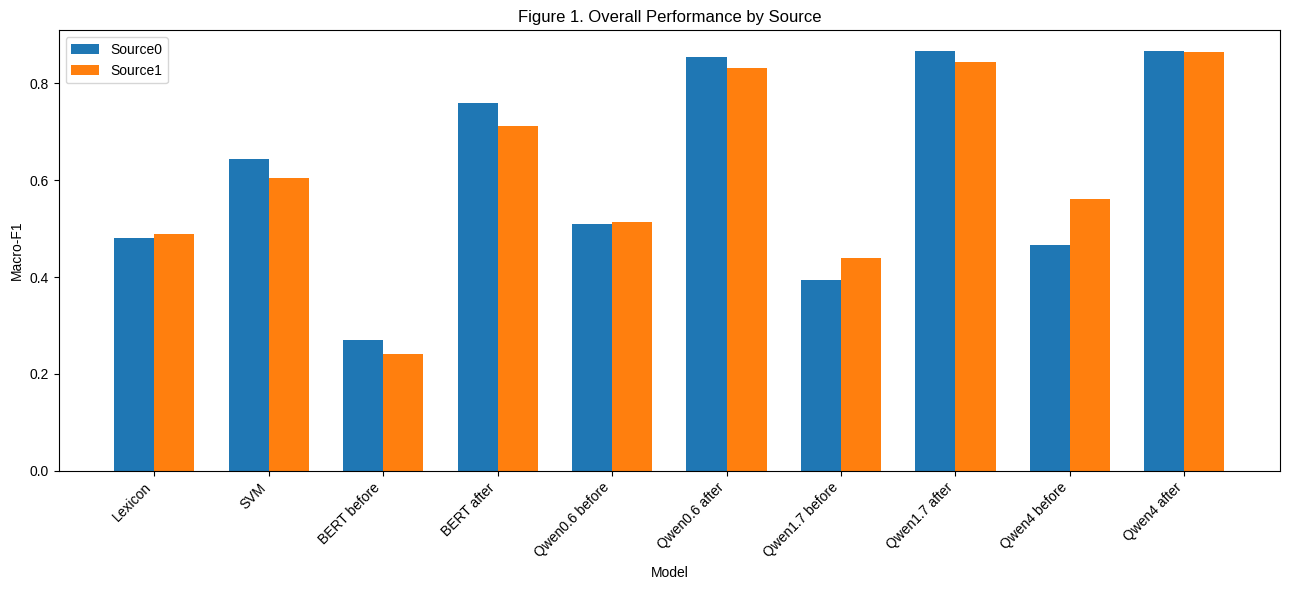

Saved: /content/drive/MyDrive/NLP_project/results/experiment_A_outputs/figure1_overall_performance_by_source.png


In [75]:
import os
import numpy as np
import matplotlib.pyplot as plt

df_plot = table1.copy()
df_plot["Model"] = df_plot["Model"].astype(str)
df_plot["Source"] = df_plot["Source"].astype(str)

model_order = [
    "Lexicon",
    "SVM",
    "BERT before",
    "BERT after",
    "Qwen0.6 before",
    "Qwen0.6 after",
    "Qwen1.7 before",
    "Qwen1.7 after",
    "Qwen4 before",
    "Qwen4 after"
]

models = [m for m in model_order if m in df_plot["Model"].unique()]

x = np.arange(len(models))
width = 0.35

source0_vals = []
source1_vals = []

for m in models:
    s0 = df_plot[(df_plot["Model"] == m) & (df_plot["Source"] == "source0")]
    s1 = df_plot[(df_plot["Model"] == m) & (df_plot["Source"] == "source1")]

    source0_vals.append(s0["Macro_F1"].values[0] if len(s0) > 0 else np.nan)
    source1_vals.append(s1["Macro_F1"].values[0] if len(s1) > 0 else np.nan)

plt.figure(figsize=(13, 6))
plt.bar(x - width/2, source0_vals, width=width, label="Source0")
plt.bar(x + width/2, source1_vals, width=width, label="Source1")

plt.xticks(x, models, rotation=45, ha="right")
plt.ylabel("Macro-F1")
plt.xlabel("Model")
plt.title("Figure 1. Overall Performance by Source")
plt.legend()
plt.tight_layout()

save_path_1 = os.path.join(OUTPUT_DIR, "figure1_overall_performance_by_source.png")
plt.savefig(save_path_1, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path_1)

### Figure 2 — Mean Performance Ranking

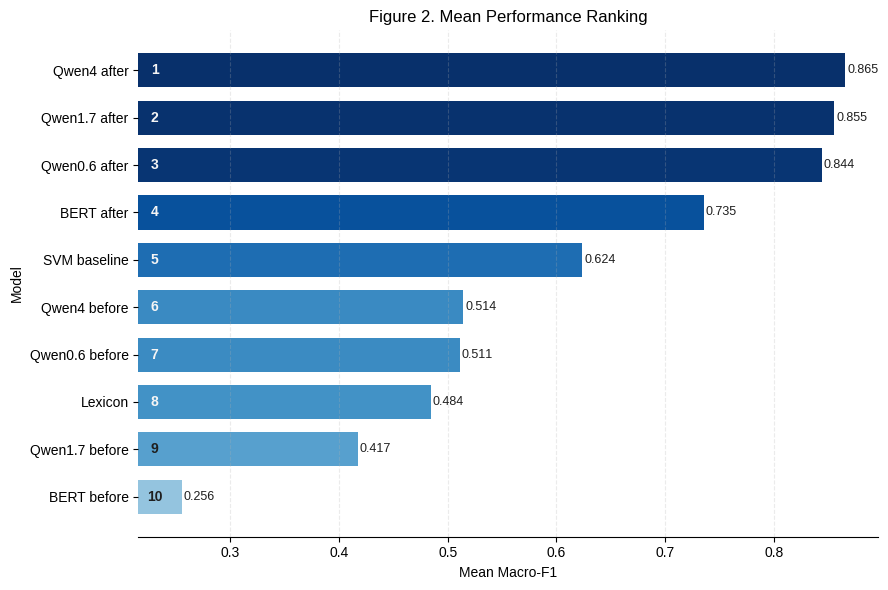

Saved: /content/drive/MyDrive/NLP_project/results/experiment_A_outputs/figure2_mean_performance_contrast_rank.png


In [76]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

plt.rcParams["font.family"] = "Liberation Sans"

df_plot = table2.copy()
df_plot["Model"] = df_plot["Model"].astype(str)

df_plot = df_plot.dropna(subset=["Mean_Macro_F1"]).copy()

df_plot = df_plot.sort_values(by="Mean_Macro_F1", ascending=True).reset_index(drop=True)

values = df_plot["Mean_Macro_F1"].to_numpy(dtype=float)
labels = df_plot["Model"].to_list()
y = np.arange(len(df_plot))

cmap = plt.cm.Blues
norm = Normalize(vmin=np.min(values), vmax=np.max(values))
bar_colors = cmap(0.4 + 0.6 * norm(values))

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    y,
    values,
    color=bar_colors,
    edgecolor="none",
    height=0.72
)

for i, v in enumerate(values):
    ax.text(
        v + 0.002,
        i,
        f"{v:.3f}",
        va="center",
        ha="left",
        fontsize=9,
        color="#1f1f1f"
    )

rank_x = np.min(values) - 0.025

for i, v in enumerate(values):
    rank = f"{len(values) - i}"
    r, g, b, _ = bar_colors[i]

    luminance = 0.299 * r + 0.587 * g + 0.114 * b

    rank_color = "#f5f5f5" if luminance < 0.55 else "#1f1f1f"

    ax.text(
        rank_x,
        i,
        rank,
        va="center",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=rank_color
    )

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Mean Macro-F1", fontsize=10)
ax.set_ylabel("Model", fontsize=10)
ax.set_title("Figure 2. Mean Performance Ranking", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.25)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.set_xlim(np.min(values) - 0.04, np.max(values) + 0.03)

plt.tight_layout()

save_path_2 = os.path.join(OUTPUT_DIR, "figure2_mean_performance_contrast_rank.png")
plt.savefig(save_path_2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path_2)

## **Experiment B: Cross-Source Generalization and Stability**

In [77]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

LABELS = [-1, 0, 1]
NEUTRAL_LABEL = 0

def compute_experiment_b_metrics(df):
    y_true = df["label"]
    y_pred = df["prediction"]

    accuracy = accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        average="macro",
        zero_division=0
    )

    per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        average=None,
        zero_division=0
    )

    label_to_f1 = dict(zip(LABELS, per_class_f1))
    neutral_f1 = label_to_f1[NEUTRAL_LABEL]

    return pd.Series({
        "Accuracy": accuracy,
        "Macro_F1": macro_f1,
        "Neutral_F1": neutral_f1
    })

### Table 2: Cross-Source Robustness Table

In [78]:
df = table1.copy()

wide = df.pivot(index="Model", columns="Source", values=[
    "Accuracy",
    "Macro_Precision",
    "Macro_Recall",
    "Macro_F1"
])

wide.columns = [f"{metric}_{source}" for metric, source in wide.columns]
wide = wide.reset_index()

wide["Accuracy Gap"] = (wide["Accuracy_source0"] - wide["Accuracy_source1"]).abs()
wide["Macro-P Gap"] = (wide["Macro_Precision_source0"] - wide["Macro_Precision_source1"]).abs()
wide["Macro-R Gap"] = (wide["Macro_Recall_source0"] - wide["Macro_Recall_source1"]).abs()
wide["Macro-F1 Gap"] = (wide["Macro_F1_source0"] - wide["Macro_F1_source1"]).abs()

gap_table = wide[[
    "Model",
    "Accuracy Gap",
    "Macro-P Gap",
    "Macro-R Gap",
    "Macro-F1 Gap"
]].copy()

gap_table = gap_table.sort_values(by="Macro-F1 Gap", ascending=True)

gap_table = gap_table.round(4)

display(gap_table)

gap_table.to_csv(
    os.path.join(OUTPUT_DIR, "table_B1_multi_metric_gap.csv"),
    index=False
)

print("Saved: table_B1_multi_metric_gap.csv")

,Model,Accuracy Gap,Macro-P Gap,Macro-R Gap,Macro-F1 Gap
9,Qwen4 after,0.0162,0.0177,0.0413,0.0016
4,Qwen0.6 before,0.0124,0.0039,0.0025,0.0034
0,Lexicon,0.0203,0.0238,0.0011,0.0085
7,Qwen1.7 after,0.0079,0.0299,0.0078,0.0221
5,Qwen0.6 after,0.0058,0.0564,0.0052,0.0230
2,BERT before,0.0992,0.3646,0.0062,0.0301
1,SVM,0.0260,0.2318,0.0287,0.0400
6,Qwen1.7 before,0.0611,0.0385,0.0288,0.0458
3,BERT after,0.0035,0.0635,0.0326,0.0463
8,Qwen4 before,0.1093,0.0995,0.0724,0.0941


Saved: table_B1_multi_metric_gap.csv


### Figure 3: Cross-Source Stability Comparison (Multi-Metric Gap)

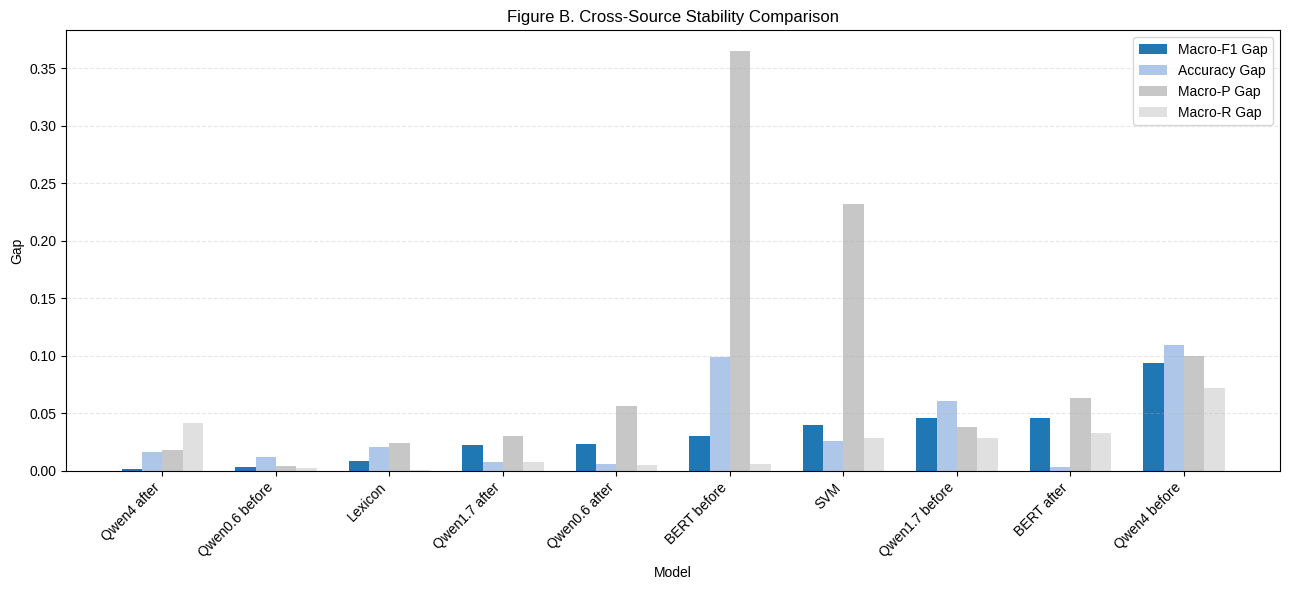

In [79]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = gap_table.copy()

plot_df = plot_df.sort_values(by="Macro-F1 Gap", ascending=True)

models = plot_df["Model"].tolist()
x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(13,6))

plt.bar(
    x - 1.5*width,
    plot_df["Macro-F1 Gap"],
    width,
    color="#1f77b4",
    label="Macro-F1 Gap"
)

plt.bar(
    x - 0.5*width,
    plot_df["Accuracy Gap"],
    width,
    color="#aec7e8",
    label="Accuracy Gap"
)

plt.bar(
    x + 0.5*width,
    plot_df["Macro-P Gap"],
    width,
    color="#c7c7c7",
    label="Macro-P Gap"
)

plt.bar(
    x + 1.5*width,
    plot_df["Macro-R Gap"],
    width,
    color="#e0e0e0",
    label="Macro-R Gap"
)

plt.xticks(x, models, rotation=45, ha="right")
plt.ylabel("Gap")
plt.xlabel("Model")
plt.title("Figure B. Cross-Source Stability Comparison")

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

## **Experiment C：Before vs After Fine-tuning Effect**

In [80]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

exp_c_models = [
    "BERT before", "BERT after",
    "Qwen0.6 before", "Qwen0.6 after",
    "Qwen1.7 before", "Qwen1.7 after",
    "Qwen4 before", "Qwen4 after"
]

c_df = table1[table1["Model"].isin(exp_c_models)].copy()
c_df["Model"] = c_df["Model"].astype(str)
c_df["Source"] = c_df["Source"].astype(str)

def get_backbone(model_name):
    if model_name.startswith("BERT"):
        return "BERT"
    if model_name.startswith("Qwen0.6"):
        return "Qwen0.6"
    if model_name.startswith("Qwen1.7"):
        return "Qwen1.7"
    if model_name.startswith("Qwen4"):
        return "Qwen4"
    return None

def get_stage(model_name):
    if "before" in model_name:
        return "before"
    if "after" in model_name:
        return "after"
    return None

c_df["Backbone"] = c_df["Model"].apply(get_backbone)
c_df["Stage"] = c_df["Model"].apply(get_stage)

backbone_order = ["BERT", "Qwen0.6", "Qwen1.7", "Qwen4"]
source_order = ["source0", "source1"]

print(c_df[["Model", "Backbone", "Stage", "Source", "Accuracy", "Macro_F1"]].head())

            Model Backbone   Stage   Source  Accuracy  Macro_F1
0   Qwen1.7 after  Qwen1.7   after  source0  0.942505  0.865997
1     Qwen4 after    Qwen4   after  source0  0.940452  0.865813
2   Qwen0.6 after  Qwen0.6   after  source0  0.940452  0.855174
3      BERT after     BERT   after  source0  0.895277  0.758371
5  Qwen0.6 before  Qwen0.6  before  source0  0.671458  0.509323


### Table 4: Fine-tuning Gain Table

In [81]:
before_df = c_df[c_df["Stage"] == "before"].copy()
after_df = c_df[c_df["Stage"] == "after"].copy()

table4 = before_df.merge(
    after_df,
    on=["Backbone", "Source"],
    suffixes=("_before", "_after")
)

table4["Delta_Macro_F1"] = table4["Macro_F1_after"] - table4["Macro_F1_before"]
table4["Delta_Accuracy"] = table4["Accuracy_after"] - table4["Accuracy_before"]

table4 = table4[[
    "Backbone",
    "Source",
    "Macro_F1_before",
    "Macro_F1_after",
    "Delta_Macro_F1",
    "Accuracy_before",
    "Accuracy_after",
    "Delta_Accuracy"
]].copy()

table4 = table4.rename(columns={
    "Backbone": "Backbone",
    "Source": "Source",
    "Macro_F1_before": "Before Macro-F1",
    "Macro_F1_after": "After Macro-F1",
    "Delta_Macro_F1": "Δ Macro-F1",
    "Accuracy_before": "Before Accuracy",
    "Accuracy_after": "After Accuracy",
    "Delta_Accuracy": "Δ Accuracy"
})

table4["Backbone"] = pd.Categorical(table4["Backbone"], categories=backbone_order, ordered=True)
table4["Source"] = pd.Categorical(table4["Source"], categories=source_order, ordered=True)

table4 = table4.sort_values(by=["Source", "Δ Macro-F1"], ascending=[True, False]).reset_index(drop=True)

display(table4.round(4))

table4.to_csv(
    os.path.join(OUTPUT_DIR, "table4_finetuning_gain.csv"),
    index=False
)

print("Saved:", os.path.join(OUTPUT_DIR, "table4_finetuning_gain.csv"))

,Backbone,Source,Before Macro-F1,After Macro-F1,Δ Macro-F1,Before Accuracy,After Accuracy,Δ Accuracy
0,BERT,source0,0.2709,0.7584,0.4875,0.6632,0.8953,0.2320
1,Qwen1.7,source0,0.3944,0.8660,0.4716,0.5318,0.9425,0.4107
2,Qwen4,source0,0.4671,0.8658,0.3987,0.6263,0.9405,0.3142
3,Qwen0.6,source0,0.5093,0.8552,0.3459,0.6715,0.9405,0.2690
4,BERT,source1,0.2407,0.7120,0.4713,0.5640,0.8988,0.3347
5,Qwen1.7,source1,0.4402,0.8439,0.4036,0.5930,0.9504,0.3574
6,Qwen0.6,source1,0.5127,0.8322,0.3195,0.6839,0.9463,0.2624
7,Qwen4,source1,0.5612,0.8642,0.3030,0.7355,0.9566,0.2211


Saved: /content/drive/MyDrive/NLP_project/results/experiment_A_outputs/table4_finetuning_gain.csv


### Figure 4: Before–After Dumbbell Plot

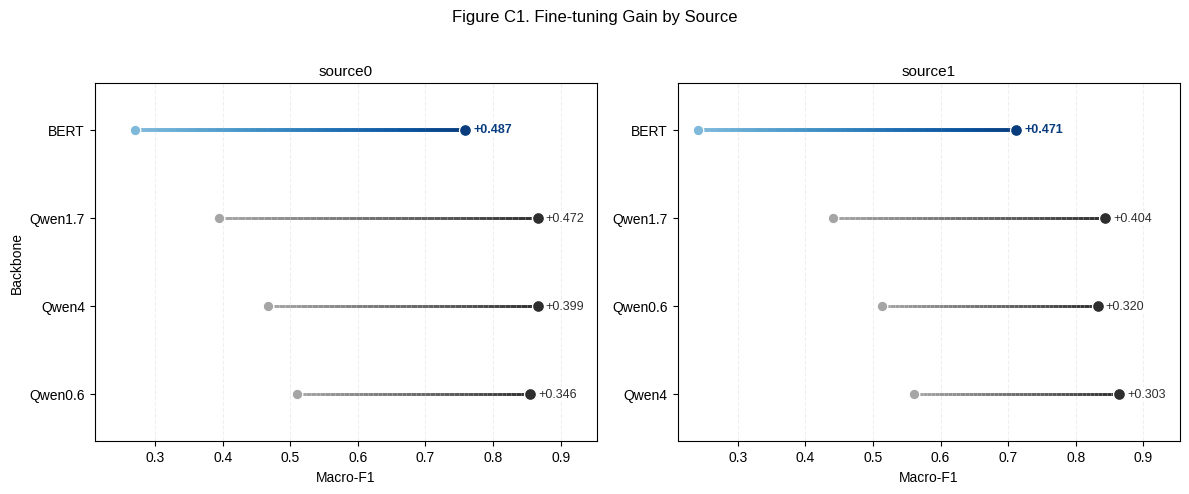

Saved: /content/drive/MyDrive/NLP_project/results/experiment_A_outputs/figureC1_gradient_dumbbell_final_aligned.png


In [82]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

plt.rcParams["font.family"] = "Liberation Sans"

plot_df = table4.copy()
plot_df["Backbone"] = plot_df["Backbone"].astype(str)
plot_df["Source"] = plot_df["Source"].astype(str)

source_order = ["source0", "source1"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

for ax, source in zip(axes, source_order):
    sub = plot_df[plot_df["Source"] == source].copy()

    sub["Delta"] = sub["After Macro-F1"] - sub["Before Macro-F1"]
    sub = sub.sort_values("Delta", ascending=False).reset_index(drop=True)

    y = np.arange(len(sub)) * 0.38
    best_i = sub["Delta"].idxmax()

    for i, row in sub.iterrows():
        before = row["Before Macro-F1"]
        after = row["After Macro-F1"]
        delta = row["Delta"]

        x_vals = np.linspace(before, after, 50)
        y_vals = np.full_like(x_vals, y[i])

        points = np.array([x_vals, y_vals]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        if i == best_i:
            cmap = plt.cm.Blues
            line_width = 2.8
            grad_start, grad_end = 0.45, 0.95
        else:
            cmap = plt.cm.Greys
            line_width = 2.1
            grad_start, grad_end = 0.45, 0.85

        grad_vals = np.linspace(grad_start, grad_end, len(segments))

        lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, 1))
        lc.set_array(grad_vals)
        lc.set_linewidth(line_width)
        lc.set_zorder(1)
        ax.add_collection(lc)

        ax.scatter(
            before,
            y[i],
            color=cmap(grad_start),
            s=58,
            edgecolor="white",
            linewidth=0.9,
            zorder=3
        )

        ax.scatter(
            after,
            y[i],
            color=cmap(grad_end),
            s=74,
            edgecolor="white",
            linewidth=0.9,
            zorder=3
        )

        ax.text(
            after + 0.012,
            y[i],
            f"+{delta:.3f}",
            va="center",
            ha="left",
            fontsize=9,
            color=cmap(grad_end),
            fontweight="bold" if i == best_i else "normal",
            bbox=dict(facecolor="white", edgecolor="none", pad=0.6)
        )

    ax.set_yticks(y)
    ax.set_yticklabels(sub["Backbone"], fontsize=10)
    ax.set_xlabel("Macro-F1", fontsize=10)
    ax.set_title(source, fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.2)

    x_min = min(sub["Before Macro-F1"].min(), sub["After Macro-F1"].min()) - 0.03
    x_max = max(sub["Before Macro-F1"].max(), sub["After Macro-F1"].max()) + 0.09
    ax.set_xlim(x_min, x_max)

    ax.set_ylim(y.max() + 0.20, y.min() - 0.20)

axes[0].set_ylabel("Backbone", fontsize=10)

fig.suptitle("Figure C1. Fine-tuning Gain by Source", y=1.02, fontsize=12)

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "figureC1_gradient_dumbbell_final_aligned.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

### Figure 5： Fine-tuning Gain Heatmap (Δ Macro-F1 Across Backbones and Sources)

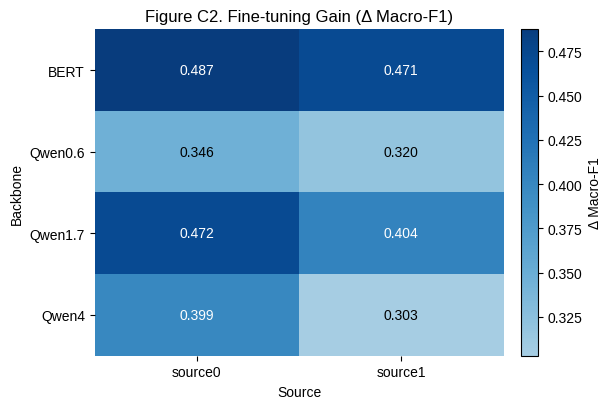

Saved: /content/drive/MyDrive/NLP_project/results/experiment_A_outputs/figureC2_heatmap_clean_blue.png


In [83]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "Liberation Sans"

plot_df = table4.copy()

backbone_order = ["BERT", "Qwen0.6", "Qwen1.7", "Qwen4"]
source_order = ["source0", "source1"]

heatmap_df = plot_df.pivot(index="Backbone", columns="Source", values="Δ Macro-F1")
heatmap_df = heatmap_df.reindex(index=backbone_order, columns=source_order)

data = heatmap_df.values

base_cmap = plt.cm.Blues
colors = base_cmap(np.linspace(0.35, 0.95, 256))
custom_cmap = LinearSegmentedColormap.from_list("custom_blues", colors)

plt.figure(figsize=(6.2, 4.2))

im = plt.imshow(data, aspect="auto", cmap=custom_cmap)

plt.xticks(np.arange(len(source_order)), source_order, fontsize=10)
plt.yticks(np.arange(len(backbone_order)), backbone_order, fontsize=10)

plt.xlabel("Source", fontsize=10)
plt.ylabel("Backbone", fontsize=10)
plt.title("Figure C2. Fine-tuning Gain (Δ Macro-F1)", fontsize=12)

vmin, vmax = data.min(), data.max()
threshold = (vmin + vmax) / 2

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]

        text_color = "white" if val > threshold else "black"

        plt.text(
            j,
            i,
            f"{val:.3f}",
            ha="center",
            va="center",
            fontsize=10,
            color=text_color
        )

cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("Δ Macro-F1", fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "figureC2_heatmap_clean_blue.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## **Experiment D**

In [84]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_fscore_support

EXP_D_OUTPUT_DIR = "/content/drive/MyDrive/NLP_project/results/experiment_D_outputs"
os.makedirs(EXP_D_OUTPUT_DIR, exist_ok=True)

LABELS = [-1, 0, 1]
LABEL_NAME_MAP = {
    -1: "Negative",
    0: "Neutral",
    1: "Positive"
}

selected_models = [
    "SVM",
    "BERT after",
    "Qwen1.7 after",
    "Qwen4 before",
    "Qwen4 after"
]

delta_models = [
    ("BERT before", "BERT after", "BERT"),
    ("Qwen0.6 before", "Qwen0.6 after", "Qwen0.6"),
    ("Qwen1.7 before", "Qwen1.7 after", "Qwen1.7"),
    ("Qwen4 before", "Qwen4 after", "Qwen4")
]


def compute_per_class_metrics(df):
    y_true = df["label"]
    y_pred = df["prediction"]

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABELS,
        average=None,
        zero_division=0
    )

    rows = []
    for label_value, p, r, f, s in zip(LABELS, precision, recall, f1, support):
        rows.append({
            "ClassValue": label_value,
            "Class": LABEL_NAME_MAP[label_value],
            "Precision": p,
            "Recall": r,
            "F1": f,
            "Support": s
        })

    return pd.DataFrame(rows)


per_class_results = []

for file_name, (model_name, source_name) in FILE_MAP.items():
    file_path = os.path.join(DATA_DIR, file_name)

    if not os.path.exists(file_path):
        continue

    df = pd.read_csv(file_path)

    required_cols = {"id", "review", "label", "prediction"}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"{file_name} is missing required columns: {required_cols}")

    metric_df = compute_per_class_metrics(df)
    metric_df["Model"] = model_name
    metric_df["Source"] = source_name
    metric_df["File"] = file_name

    per_class_results.append(metric_df)

per_class_table = pd.concat(per_class_results, ignore_index=True)

per_class_table = per_class_table[
    ["Model", "Source", "Class", "Precision", "Recall", "F1", "Support", "File"]
].copy()

per_class_table = per_class_table.round(4)

display(per_class_table.head(20))

per_class_table.to_csv(
    os.path.join(EXP_D_OUTPUT_DIR, "table_D_per_class_metrics.csv"),
    index=False
)

print("Saved: table_D_per_class_metrics.csv")

,Model,Source,Class,Precision,Recall,F1,Support,File
0,SVM,source0,Negative,0.7610,0.9098,0.8288,133,svm_tfidf_s0.csv
1,SVM,source0,Neutral,0.8000,0.1000,0.1778,40,svm_tfidf_s0.csv
2,SVM,source0,Positive,0.9077,0.9327,0.9201,327,svm_tfidf_s0.csv
3,SVM,source1,Negative,0.8500,0.9444,0.8947,198,svm_tfidf_s1.csv
4,SVM,source1,Neutral,0.0000,0.0000,0.0000,21,svm_tfidf_s1.csv
5,SVM,source1,Positive,0.9209,0.9110,0.9159,281,svm_tfidf_s1.csv
6,Lexicon,source0,Negative,0.6102,0.5414,0.5737,133,lexicon_rule_s0.csv
7,Lexicon,source0,Neutral,0.1111,0.0250,0.0408,40,lexicon_rule_s0.csv
8,Lexicon,source0,Positive,0.7748,0.8838,0.8257,327,lexicon_rule_s0.csv
9,Lexicon,source1,Negative,0.7630,0.5202,0.6186,198,lexicon_rule_s1.csv


Saved: table_D_per_class_metrics.csv


In [85]:
report_table_D = per_class_table[
    per_class_table["Model"].isin(selected_models)
].copy()

report_table_D = report_table_D.sort_values(
    by=["Source", "Model", "Class"],
    key=lambda col: col.map({
        "source0": 0,
        "source1": 1,
        "SVM": 0,
        "BERT after": 1,
        "Qwen1.7 after": 2,
        "Qwen4 before": 3,
        "Qwen4 after": 4,
        "Negative": 0,
        "Neutral": 1,
        "Positive": 2
    }).fillna(999)
)

display(report_table_D)

report_table_D.to_csv(
    os.path.join(EXP_D_OUTPUT_DIR, "table_D_report_selected_models.csv"),
    index=False
)

print("Saved: table_D_report_selected_models.csv")

,Model,Source,Class,Precision,Recall,F1,Support,File
0,SVM,source0,Negative,0.7610,0.9098,0.8288,133,svm_tfidf_s0.csv
1,SVM,source0,Neutral,0.8000,0.1000,0.1778,40,svm_tfidf_s0.csv
2,SVM,source0,Positive,0.9077,0.9327,0.9201,327,svm_tfidf_s0.csv
18,BERT after,source0,Negative,0.8705,0.9098,0.8897,133,bert_after_s0.csv
19,BERT after,source0,Neutral,0.5000,0.3750,0.4286,40,bert_after_s0.csv
20,BERT after,source0,Positive,0.9396,0.9511,0.9453,327,bert_after_s0.csv
42,Qwen1.7 after,source0,Negative,0.9398,0.9398,0.9398,133,qwen_1.7b_after_s0.csv
43,Qwen1.7 after,source0,Neutral,0.6383,0.7500,0.6897,40,qwen_1.7b_after_s0.csv
44,Qwen1.7 after,source0,Positive,0.9875,0.9664,0.9768,327,qwen_1.7b_after_s0.csv
48,Qwen4 before,source0,Negative,0.4455,0.7402,0.5562,127,qwen_4b_before_s0.csv


Saved: table_D_report_selected_models.csv


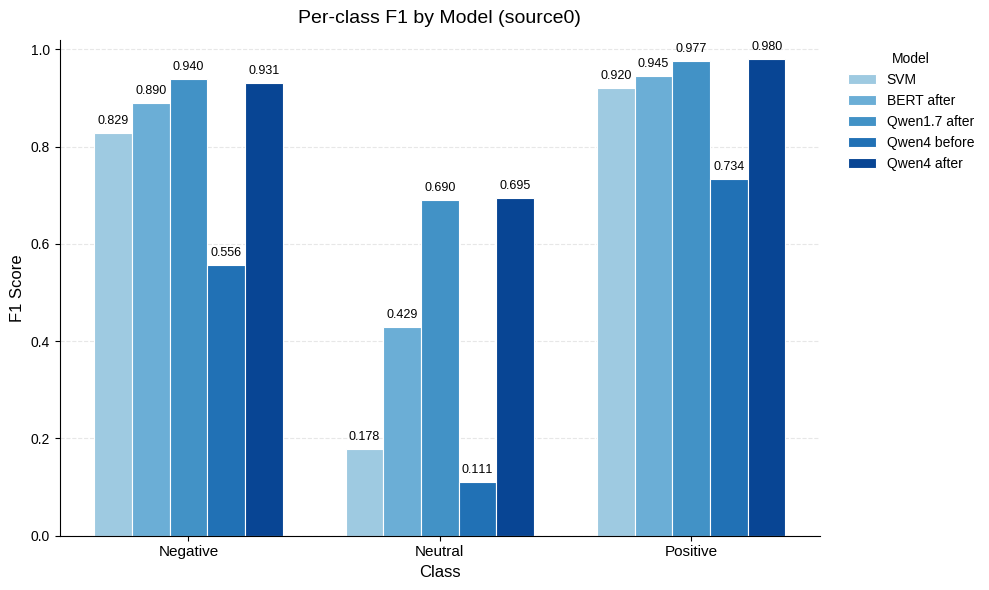

Saved: figure_D_part1_per_class_f1_source0.png


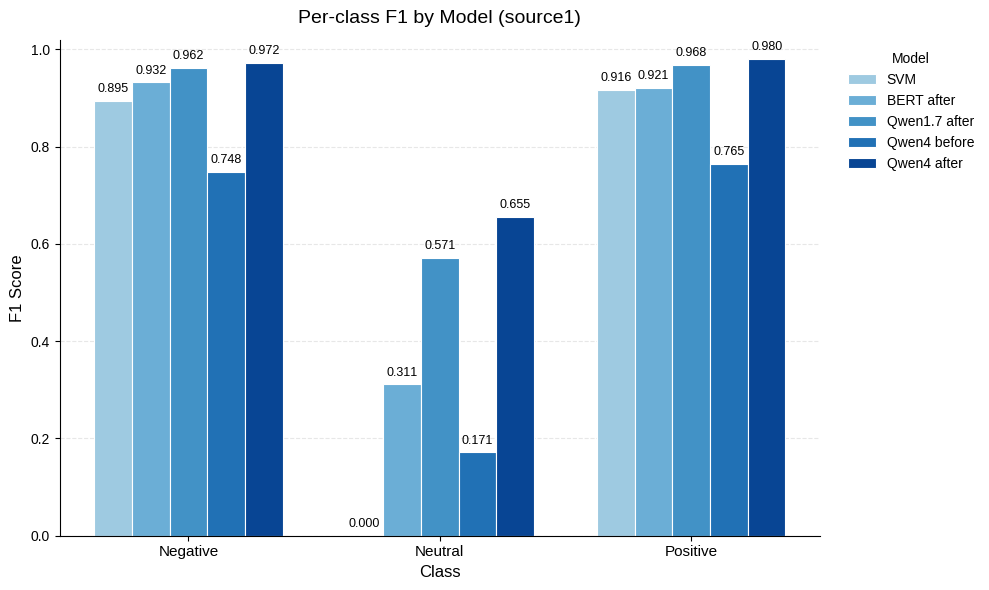

Saved: figure_D_part1_per_class_f1_source1.png


In [86]:
def plot_per_class_f1_by_source(plot_df, source_name):
    pivot_df = plot_df.pivot(index="Class", columns="Model", values="F1")
    pivot_df = pivot_df.reindex(index=class_order, columns=selected_models)

    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(class_order))
    n_models = len(selected_models)
    width = 0.15

    offsets = np.linspace(
        -width * (n_models - 1) / 2,
        width * (n_models - 1) / 2,
        n_models
    )

    for i, model_name in enumerate(selected_models):
        values = pivot_df[model_name].values
        bars = ax.bar(
            x + offsets[i],
            values,
            width=width,
            label=model_name,
            color=model_colors[model_name],
            edgecolor="white",
            linewidth=0.8
        )

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    ax.set_title(f"Per-class F1 by Model ({source_name})", fontsize=14, pad=12)
    ax.set_xlabel("Class", fontsize=12)
    ax.set_ylabel("F1 Score", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(class_order, fontsize=11)
    ax.set_ylim(0, 1.02)

    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.legend(
        title="Model",
        frameon=False,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()

    save_path = os.path.join(EXP_D_OUTPUT_DIR, f"figure_D_part1_per_class_f1_{source_name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {os.path.basename(save_path)}")

for source_name in source_order:
    plot_df = per_class_f1_table[
        per_class_f1_table["Source"] == source_name
    ].copy()

    plot_per_class_f1_by_source(plot_df, source_name)

## **Experiment E**

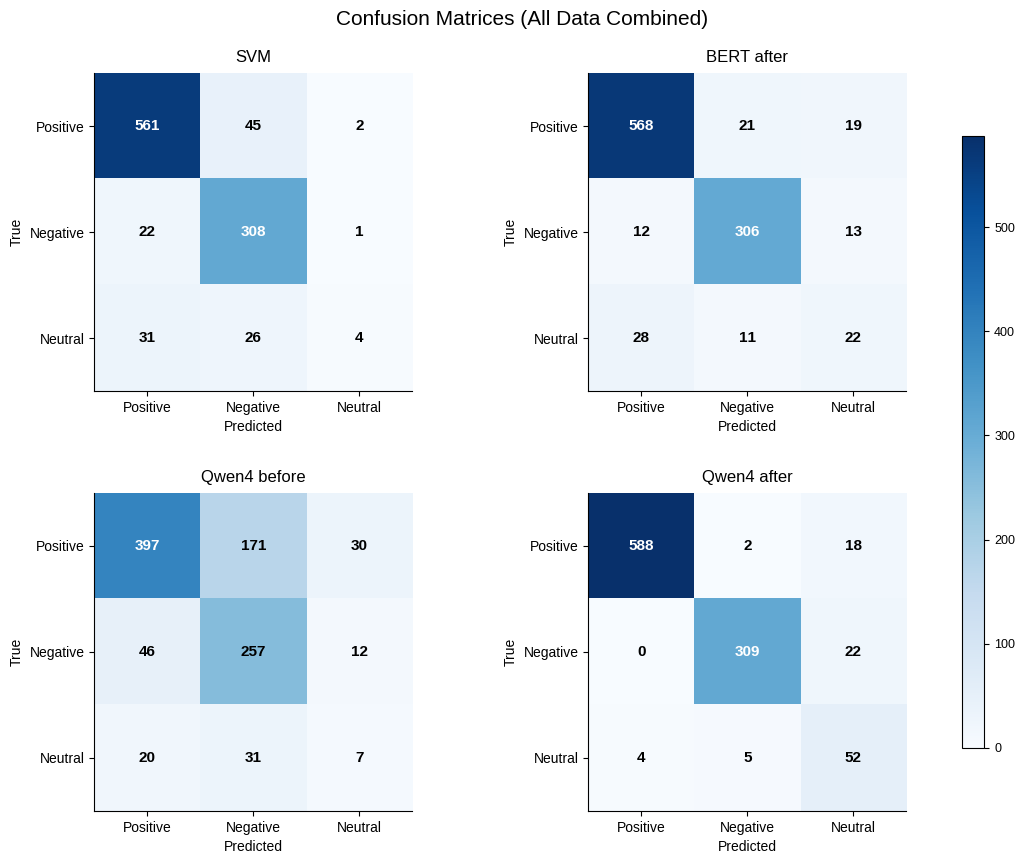

Saved: figure_E_confusion_matrices_combined_preferred_order.png


In [88]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

EXP_E_OUTPUT_DIR = "/content/drive/MyDrive/NLP_project/results/experiment_E_outputs"
os.makedirs(EXP_E_OUTPUT_DIR, exist_ok=True)

LABELS = [1, -1, 0]
LABEL_NAMES = ["Positive", "Negative", "Neutral"]

models_E = [
    "SVM",
    "BERT after",
    "Qwen4 before",
    "Qwen4 after"
]

cm_dict = {}
max_value = 0

for model in models_E:
    df_plot = full_df[full_df["Model"] == model].copy()

    if len(df_plot) == 0:
        print(f"[Skip] {model}")
        continue

    cm = confusion_matrix(
        df_plot["label"],
        df_plot["prediction"],
        labels=LABELS
    )

    cm_dict[model] = cm
    max_value = max(max_value, cm.max())

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, model in zip(axes, models_E):
    if model not in cm_dict:
        ax.axis("off")
        continue

    cm = cm_dict[model]

    im = ax.imshow(
        cm,
        interpolation="nearest",
        cmap="Blues",
        vmin=0,
        vmax=max_value
    )

    ax.set_xticks(np.arange(len(LABEL_NAMES)))
    ax.set_yticks(np.arange(len(LABEL_NAMES)))
    ax.set_xticklabels(LABEL_NAMES, fontsize=10)
    ax.set_yticklabels(LABEL_NAMES, fontsize=10)

    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_title(model, fontsize=12, pad=8)

    threshold = max_value * 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text_color = "white" if value > threshold else "black"
            ax.text(
                j, i, f"{value}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=11,
                fontweight="bold"
            )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.subplots_adjust(
    left=0.08,
    right=0.88,
    top=0.90,
    bottom=0.08,
    wspace=0.28,
    hspace=0.32
)

cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.68])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Confusion Matrices (All Data Combined)",
    fontsize=15,
    y=0.97
)

save_path = os.path.join(EXP_E_OUTPUT_DIR, "figure_E_confusion_matrices_combined_preferred_order.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_E_confusion_matrices_combined_preferred_order.png")